In [4]:
import pandas as pd
file_path = '/content/domain_properties.csv'
df = pd.read_csv(file_path)
df.head()




,price,date_sold,suburb,num_bath,num_bed,num_parking,property_size,type,suburb_population,suburb_median_income,suburb_sqkm,suburb_lat,suburb_lng,suburb_elevation,cash_rate,property_inflation_index,km_from_cbd
0,530000,13/1/16,Kincumber,4,4,2,1351,House,7093,29432,9.914,-33.47252,151.40208,24,2.0,150.9,47.05
1,525000,13/1/16,Halekulani,2,4,2,594,House,2538,24752,1.397,-33.21772,151.55237,23,2.0,150.9,78.54
2,480000,13/1/16,Chittaway Bay,2,4,2,468,House,2028,31668,1.116,-33.32678,151.44557,3,2.0,150.9,63.59
3,452000,13/1/16,Leumeah,1,3,1,344,House,9835,32292,4.055,-34.05375,150.83957,81,2.0,150.9,40.12
4,365500,13/1/16,North Avoca,0,0,0,1850,Vacant land,2200,45084,1.497,-33.45608,151.43598,18,2.0,150.9,49.98


In [3]:
print(df.columns)

Index(['price', 'date_sold', 'suburb', 'num_bath', 'num_bed', 'num_parking',
       'property_size', 'type', 'suburb_population', 'suburb_median_income',
       'suburb_sqkm', 'suburb_lat', 'suburb_lng', 'suburb_elevation',
       'cash_rate', 'property_inflation_index', 'km_from_cbd'],
      dtype='object')


In [6]:
print("=== MISSING VALUES COUNT ===")
print(df.isnull().sum())

=== MISSING VALUES COUNT ===
price                       0
date_sold                   0
suburb                      0
num_bath                    0
num_bed                     0
num_parking                 0
property_size               0
type                        0
suburb_population           0
suburb_median_income        0
suburb_sqkm                 0
suburb_lat                  0
suburb_lng                  0
suburb_elevation            0
cash_rate                   0
property_inflation_index    0
km_from_cbd                 0
dtype: int64


Total Valid Sales Analysed: 11,160
Median Sale Price: $1,388,000.00 AUD
Mean Sale Price:   $1,675,395.27 AUD

--- TOP 10 SUBURBS BY MARKET ACTIVITY ---
           suburb  sales_count  median_price
0      Bateau Bay           68      770000.0
1     Castle Hill           62     1839500.0
2  Baulkham Hills           59     1585000.0
3      Kellyville           57     1380000.0
4   Glenmore Park           56      888500.0
5     Green Point           54      905000.0
6        St Clair           54      765000.0
7       Oran Park           51      807000.0
8   Berkeley Vale           50      605000.0
9      Toongabbie           50      873000.0


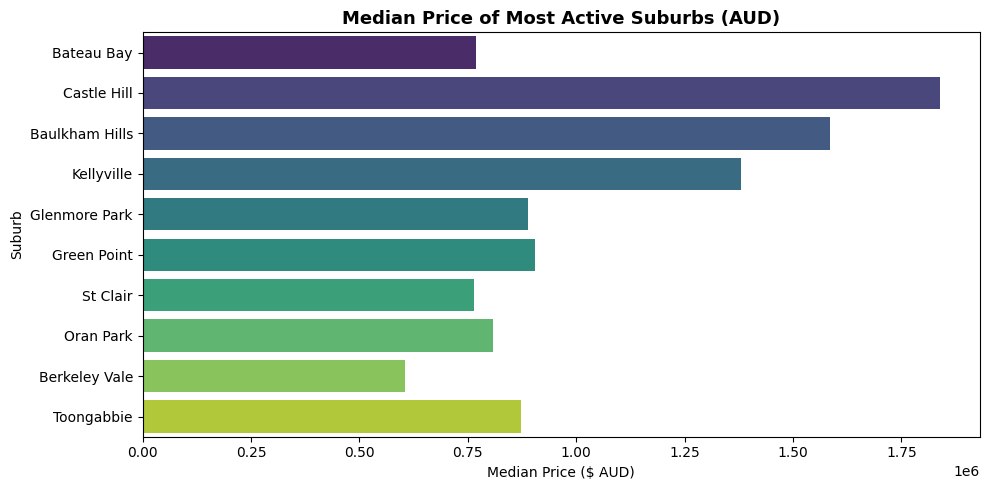

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Key Economic Indicators
median_price = df['price'].median()
mean_price = df['price'].mean()

print(f"Total Valid Sales Analysed: {len(df):,}")
print(f"Median Sale Price: ${median_price:,.2f} AUD")
print(f"Mean Sale Price:   ${mean_price:,.2f} AUD")

# Aggregate Top Suburbs by Sales Volume
top_suburbs = (
    df.groupby('suburb')['price']
    .agg(sales_count='count', median_price='median')
    .sort_values(by='sales_count', ascending=False)
    .head(10)
    .reset_index()
)

print("\n--- TOP 10 SUBURBS BY MARKET ACTIVITY ---")
print(top_suburbs)

# Generate & Save Visualisation
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_suburbs,
    x='median_price',
    y='suburb',
    hue='suburb',
    legend=False,
    palette='viridis'
)
plt.title('Median Price of Most Active Suburbs (AUD)', fontsize=13, fontweight='bold')
plt.xlabel('Median Price ($ AUD)')
plt.ylabel('Suburb')
plt.tight_layout()

# Save image file to Colab session storage
plt.savefig('suburb_price_breakdown.png', dpi=300)
plt.show()